In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


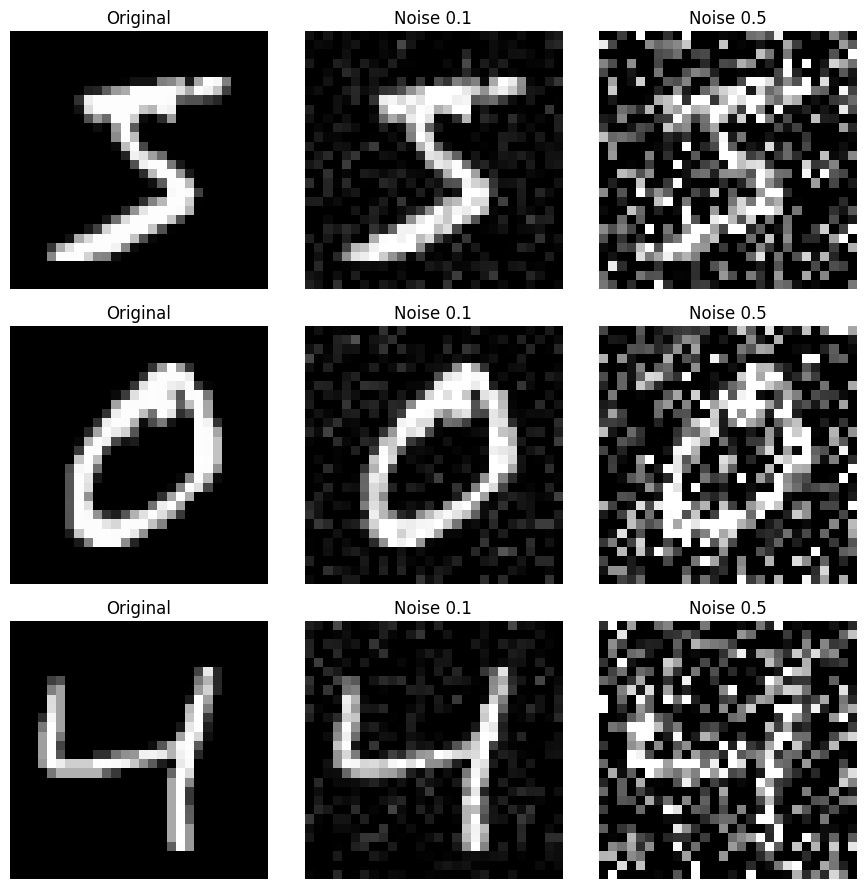

In [3]:
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title("Original")
  plt.axis('off')
  # Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.1")
  plt.axis('off')
  # High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.5")
  plt.axis('off')
plt.tight_layout()


In [4]:
def build_encoder(input_shape=(28, 28, 1)):
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [5]:
def build_decoder(encoded_input):
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [6]:
def build_autoencoder():
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [7]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder = build_autoencoder()

history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_test_noisy_high, x_test)
  )

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 214s 451ms/step - loss: 0.1521 - val_loss: 0.1122
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 231s 385ms/step - loss: 0.1093 - val_loss: 0.1044
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 207s 395ms/step - loss: 0.1039 - val_loss: 0.1013
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 181s 385ms/step - loss: 0.1014 - val_loss: 0.0996
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 182s 389ms/step - loss: 0.0999 - val_loss: 0.0985
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 174s 370ms/step - loss: 0.0987 - val_loss: 0.0974
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 210s 387ms/step - loss: 0.0978 - val_loss: 0.0968
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 179s 381ms/step - loss: 0.0970 - val_loss: 0.0959
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 397ms/step - loss: 0.0964 - val_loss: 0.0956
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 183s 391ms/step - loss: 0.0959 - val_loss: 0.0951


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


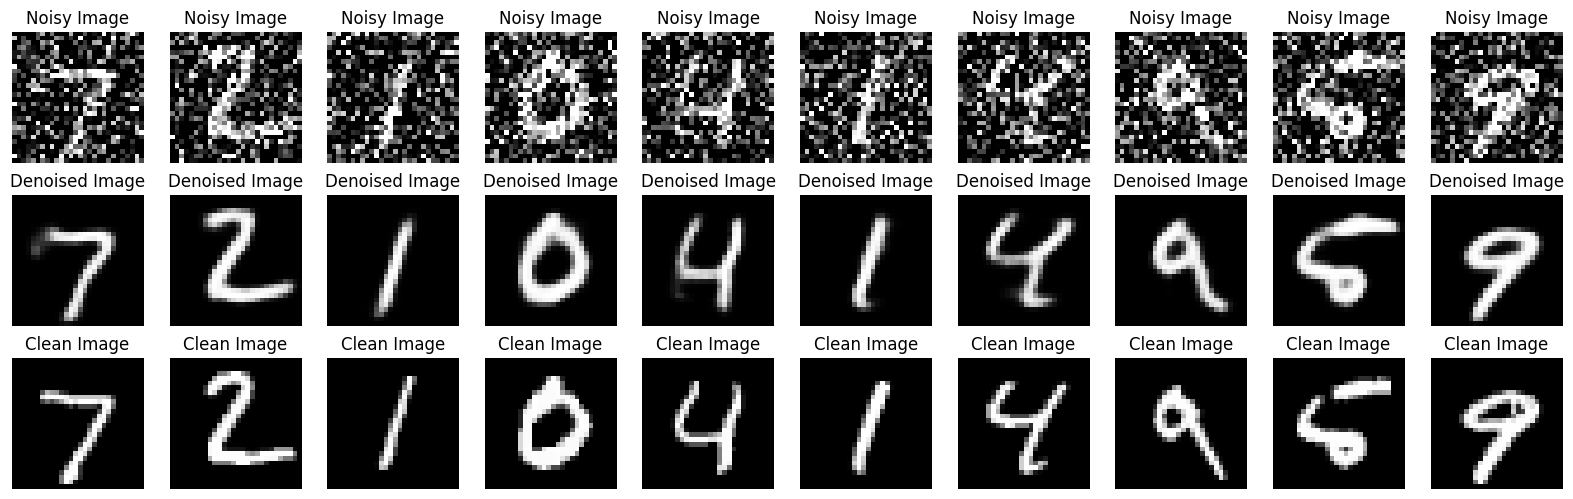

In [11]:
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):

    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Image")
    plt.axis('off')

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Image")
    plt.axis('off')

    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [16]:
def load_images(data_dir, img_size=(28,28)):
    images = []

    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, file)

                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize(img_size)

                img = np.array(img)
                images.append(img)

    images = np.array(images)
    return images

# Load dataset (change path accordingly)
data_dir = "/content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset/Test"
images = load_images(data_dir)

print("Dataset shape:", images.shape)

Dataset shape: (3000, 28, 28)


In [17]:
# Normalize
images = images.astype('float32') / 255.0

# Reshape to (samples, height, width, channels)
images = np.reshape(images, (len(images), 28, 28, 1))

# Train-test split
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)

Train: (2400, 28, 28, 1)
Validation: (600, 28, 28, 1)


In [18]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy = x_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

# Clip values to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

In [19]:
input_img = Input(shape=(28, 28, 1))

# 🔹 Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# 🔹 Bottleneck
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

# 🔹 Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 775ms/step - loss: 0.5422 - val_loss: 0.3856
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 577ms/step - loss: 0.3439 - val_loss: 0.2992
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 450ms/step - loss: 0.2784 - val_loss: 0.2614
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - loss: 0.2503 - val_loss: 0.2403
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 455ms/step - loss: 0.2351 - val_loss: 0.2326
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 550ms/step - loss: 0.2257 - val_loss: 0.2192
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 472ms/step - loss: 0.2167 - val_loss: 0.2154
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 534ms/step - loss: 0.2118 - val_loss: 0.2107
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 516ms/step - loss: 0.2096 - val_loss: 0.2071
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 483ms/step - loss: 0.2067 - val_loss: 0.2048
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 581ms/step - loss: 0.2044 - val_loss: 0.2027
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10

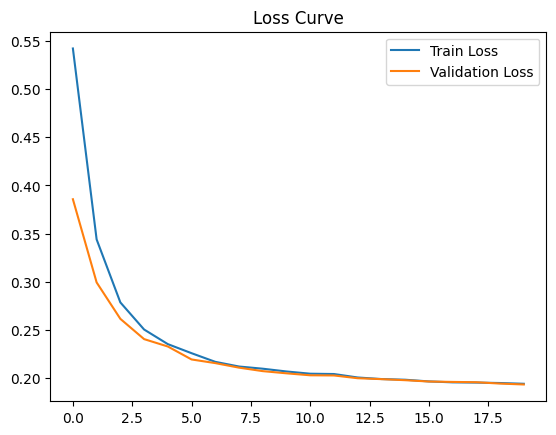

In [21]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


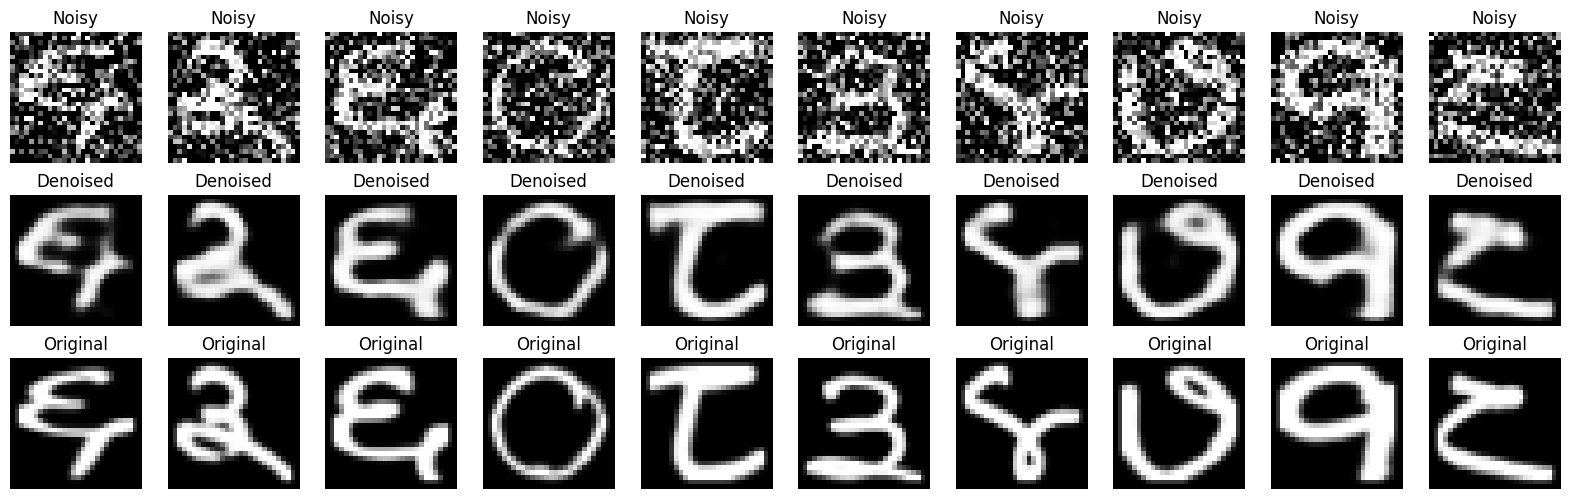

In [22]:
decoded_imgs = autoencoder.predict(x_val_noisy)

n = 10
plt.figure(figsize=(20,6))

for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_val_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_val[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()